In [1]:
import torch
from torchvision import datasets
import matplotlib.pyplot as plt


In [2]:
data_path = '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10(data_path, train = True, download = True)
cifar10_val = datasets.CIFAR10(data_path, train = False , download = True)

In [3]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [4]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


In [5]:
img, label  = cifar10[99]
img, label, class_names[label]

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

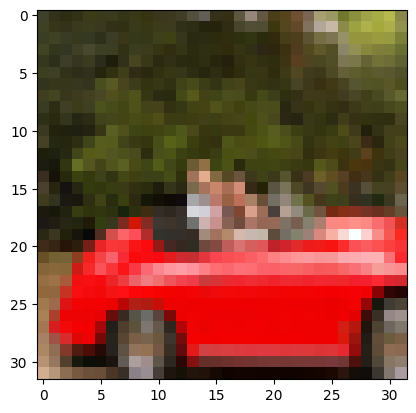

In [6]:
plt.imshow(img)
plt.show()

In [7]:
from torchvision import transforms
dir(transforms)


['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [8]:
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [9]:
tensor_cifar10 = datasets.CIFAR10(data_path, train = True, download = False, transform = transforms.ToTensor())

In [10]:
img_t , _ = tensor_cifar10[99]
type(img_t)

torch.Tensor

In [11]:
img_t.shape , img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

In [12]:
img_t.min() , img_t.max()

(tensor(0.), tensor(1.))

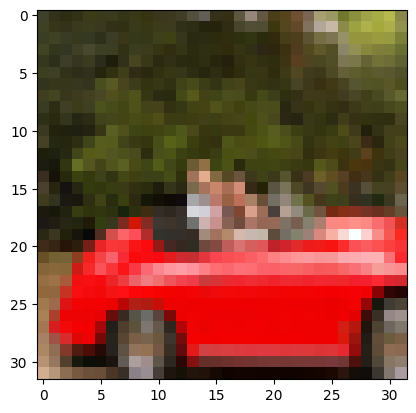

In [13]:
plt.imshow(img_t.permute(1,2,0))
plt.show()

In [14]:
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim = 3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [15]:
imgs.view(3, -1).mean(dim = 1)

tensor([0.4914, 0.4822, 0.4465])

In [16]:
imgs.view(3, -1).std(dim = 1)

tensor([0.2470, 0.2435, 0.2616])

In [17]:
transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])

Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])

In [18]:
transformed_cifar10 = datasets.CIFAR10(
    data_path, 
    train = True,
    download = False,
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
]))


transformed_cifar10_val = datasets.CIFAR10(
    data_path, 
    train = False,
    download = False,
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])
]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802876..2.1264887].


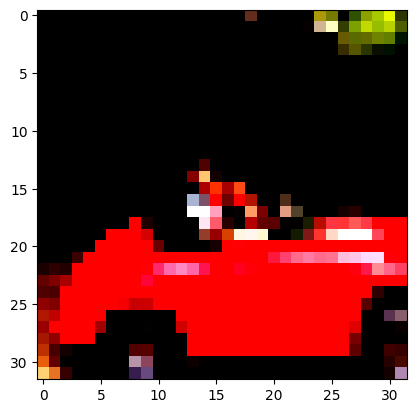

In [19]:
img_t, _ = transformed_cifar10[99]
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

In [20]:
label_map ={0: 0, 2: 1}
class_names = ['airplane', 'bird']

cifar2 = [(img, label_map[label])
          for img, label in transformed_cifar10
          if label in [0,2]]

cifar2_val = [(img, label_map[label])
               for img, label in transformed_cifar10_val
               if label in [0,2]]

In [21]:
import torch.nn as nn

n_out = 2
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512,n_out),
)

In [22]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

In [23]:
model = nn.Sequential(
    nn.Linear(3072,512),
    nn.Tanh(),
    nn.Linear(512,2),
    nn.LogSoftmax(dim = 1),
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].


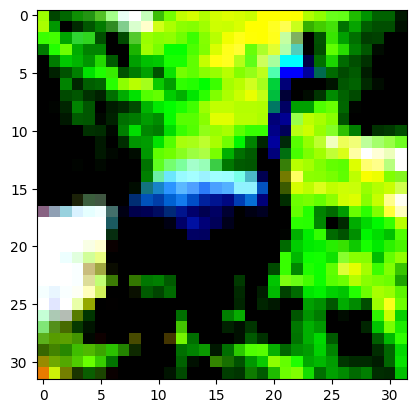

In [24]:
img, _ = cifar2[0]
plt.imshow(img.permute(1,2,0))
plt.show()

In [25]:
img_batch = img.view(-1).unsqueeze(0)
img_batch

tensor([[ 0.6143, -0.3224, -0.1160,  ..., -1.2721, -1.3170, -1.0472]])

In [26]:
out = model(img_batch)
out

tensor([[-0.4141, -1.0816]], grad_fn=<LogSoftmaxBackward0>)

In [27]:
loss = nn.NLLLoss()

In [28]:
loss(out, torch.tensor([label]))

tensor(1.0816, grad_fn=<NllLossBackward0>)

In [29]:
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(3072,512),
    nn.Tanh(),
    nn.Linear(512,2),
    nn.LogSoftmax(dim = 1),
)


learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr = learning_rate)
loss_fn = nn.NLLLoss()
n_epochs=5

for epoch in range (1, 1+n_epochs):
    for img , label in cifar2:
        out = model(img.view(-1).unsqueeze(0))
        loss = loss_fn(out, torch.tensor([label]))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("epoch: %d, loss: %f" %(epoch, float(loss)))


C:\Users\Admin\AppData\Local\Temp\ipykernel_21636\3168271805.py:24: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print("epoch: %d, loss: %f" %(epoch, float(loss)))


epoch: 1, loss: 6.313519
epoch: 2, loss: 5.373406
epoch: 3, loss: 9.988840
epoch: 4, loss: 9.296223
epoch: 5, loss: 3.278074


In [30]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size = 64, shuffle = True)

In [31]:
model = nn.Sequential(
    nn.Linear(3072,512),
    nn.Tanh(),
    nn.Linear(512,2),
    nn.LogSoftmax(dim = 1),
)


learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr = learning_rate)
loss_fn = nn.NLLLoss()
n_epochs=5

for epoch in range (1, 1+n_epochs):
    for imgs , labels in train_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("epoch: %d, loss: %f" %(epoch, float(loss)))

epoch: 1, loss: 0.439705
epoch: 2, loss: 0.395673
epoch: 3, loss: 0.422685
epoch: 4, loss: 0.523636
epoch: 5, loss: 0.317875


In [32]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size = 64, shuffle = False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim = 1) 
        total += labels.shape[0]
        correct += int ((predicted == labels).sum())
    print("accuracy: %f" %(correct / total))
    

accuracy: 0.799500


In [33]:
linear = nn.Linear(3072, 1024)
linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))